# Neural ODEs Notebook

## Imports

In [2]:
using Pkg
Pkg.add("ComponentArrays")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [3]:
using ComponentArrays, Lux, DiffEqFlux, OrdinaryDiffEq, Optimization, OptimizationOptimJL,
      OptimizationOptimisers, Random, Plots, Zygote, SciMLSensitivity, Statistics

rng = Xoshiro(0)

Xoshiro(0xdb2fa90498613fdf, 0x48d73dc42d195740, 0x8c49bc52dc8a77ea, 0x1911b814c02405e8, 0x22a21880af5dc689)

## Data Preparation

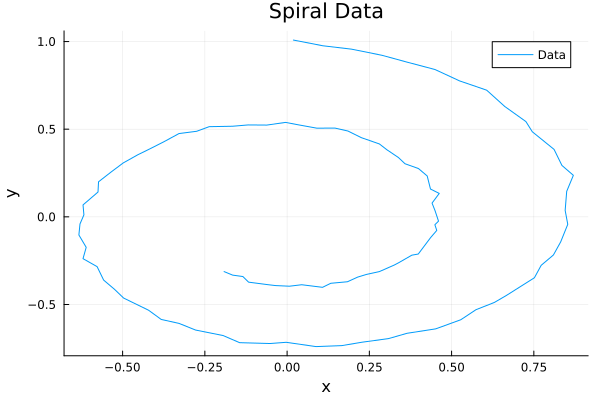

In [4]:
function generate_spiral_data(t, noise_std=0.01)
    x = sin.(t) .* exp.(-0.1 .* t)
    y = cos.(t) .* exp.(-0.1 .* t)
    
    x .+= randn(length(t)) .* noise_std
    y .+= randn(length(t)) .* noise_std
    
    return hcat(x, y)  
end

const tspan = (0f0, 10f0) 
const t = range(tspan[1], stop=tspan[2], length=100)
const data = Float32.(generate_spiral_data(t))
const u0 = data[1, :]

plot(
    data[:, 1], 
    data[:, 2], 
    label="Data", 
    title="Spiral Data", 
    xlabel="x", 
    ylabel="y",
    legend=:topright
)

## Neural ODE Definition

$$\frac{d\mathbf{y}(t)}{dt} = f_\theta(\mathbf{y}(t), t) = \text{Linear}(2 \to 50) \xrightarrow{\tanh} \text{Linear}(50 \to 2)$$

In [5]:
ODEFun = Chain(
    Dense(2, 50, tanh),
    Dense(50, 2)
)

p, st = Lux.setup(rng, ODEFun)
probNeuralOde = NeuralODE(
    ODEFun, 
    tspan, 
    Tsit5(), 
    saveat = t
)

function predict_neural_ode(p)
    Array(probNeuralOde(u0, p, st)[1])
end

function loss_neural_ode(p)
    pred = predict_neural_ode(p)
    return mean(abs2, pred .- data')
end

loss_neural_ode (generic function with 1 method)

## Training

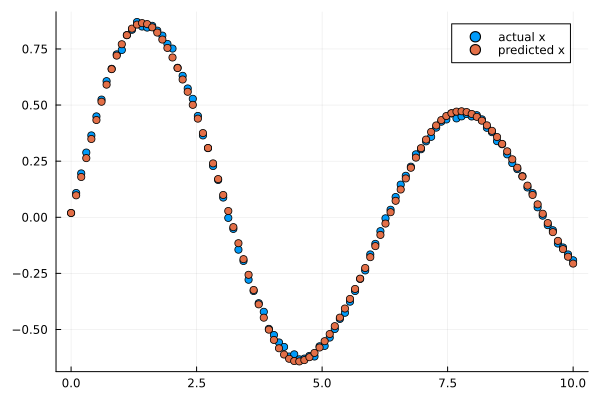

false

In [6]:
callback = let iter = 0
    function (state, l; doplot=false)
        iter += 1
        
        if iter == 1 || iter % 100 == 0 || doplot
            println("Iteration: ", iter, " | Current loss: ", l)
            
            pred = predict_neural_ode(state.u)
            plt = scatter(t, data[:, 1]; label = "actual x")
            scatter!(plt, t, pred[1, :]; label = "predicted x")
            
            IJulia.clear_output(true) 
            display(plot(plt))
        end
        return false
    end
end

pinit = Float32.(ComponentArray(p))
callback((; u = pinit), loss_neural_ode(pinit))

adtype = Optimization.AutoZygote()

optf = Optimization.OptimizationFunction((x, p) -> loss_neural_ode(x), adtype)
optprob = Optimization.OptimizationProblem(optf, pinit)

result_neural_ode = Optimization.solve(
    optprob,
    OptimizationOptimisers.Adam(0.001);
        callback = callback,
        maxiters = 200
)

optprob2 = remake(optprob, u0 = result_neural_ode.u)

result_neural_ode2 = Optimization.solve(
    optprob2,
    OptimizationOptimJL.BFGS(; initial_stepnorm = 0.01f0); 
        callback = callback,
        maxiters = 100
)

callback((; u = result_neural_ode2.u), loss_neural_ode(result_neural_ode2.u); doplot = true)

## Metrics and Visualization

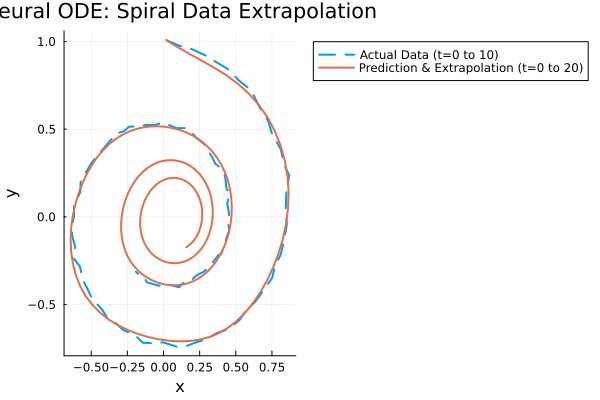

In [7]:

# 1. Setup extrapolation timespan (twice the time)
tspan_extrap = (0f0, 20f0)
t_extrap = range(tspan_extrap[1], stop=tspan_extrap[2], length=200)

# 2. Create a new NeuralODE instance for the extended timespan
probNeuralOde_extrap = NeuralODE(ODEFun, tspan_extrap, Tsit5(), saveat = t_extrap)

# 3. Predict using the trained parameters
pred_extrap = Array(probNeuralOde_extrap(u0, result_neural_ode2.u, st)[1])

# 4. Plot actual data (x vs y)
plt = plot(
    data[:, 1], 
    data[:, 2], 
    label="Actual Data (t=0 to 10)", 
    linewidth=2,
    linestyle=:dash
)

# 5. Overlay the extrapolated prediction (x vs y)
plot!(
    plt,
    pred_extrap[1, :], 
    pred_extrap[2, :], 
    label="Prediction & Extrapolation (t=0 to 20)",
    title="Neural ODE: Spiral Data Extrapolation",
    xlabel="x",
    ylabel="y",
    legend=:outertopright,
    linewidth=2
)

display(plt)